<h1 style="color:orange; font-weight:bold">🤖 K-Nearest Neighbors (KNN)</h1>


<div align="center">

<img src="13_knn.png" alt="Missing Values Handling — From Basic to Advanced" width="100%">

</div>

**K-Nearest Neighbors (KNN)** is a simple and versatile Machine Learning algorithm that predicts a new data point by finding its **nearest neighbors**.

### 📚 KNN Approach

KNN is mainly used for:

* 🏷️ **Classification**
* 📈 **Regression**

### 📏 Distance Measures

KNN uses distance to find the nearest neighbors. Common methods are **Euclidean, Manhattan, Minkowski, and Hamming Distance**.
*Only mentioned here; detailed mathematics is not covered.*

### 🌍 Applications

KNN is used in **Recommendation Systems, Financial Services, Banking, Healthcare, and Fraud Detection**.

**🏦 Example — Fraud Detection:**
If a customer's usual transactions are `$10, $15, $20`, but suddenly a `$100,000` transaction appears, KNN can compare it with similar historical transactions and flag it as **potentially suspicious**.

### ⚠️ Disadvantages

* 💻 **Computationally Expensive** → More data means more distance calculations.
* ⚖️ **Sensitive to Imbalanced Data** → A majority class can dominate the prediction.
* 🎯 **Sensitive to Irrelevant Features** → Unnecessary features can affect distance calculations.

> 💡 **Rule:** KNN → **Find nearest neighbors → Make a prediction based on those neighbors.**
---
---


<h3 style="color:orange; font-weight:bold">🏷️ KNN Classification</h3>

KNN Classification is used when the target is a categorical class. It finds the K nearest neighbors and predicts the class based on the majority vote (Mode).

📚 Types
1️⃣ Binary Classification → 2 classes
2️⃣ Multi-Class Classification → 3 or more classes
🧠 Example

K = 5

Nearest neighbors:

Cat, Dog, Cat, Cat, Dog

Mode = Cat → Prediction = Cat 🐱

💡 Rule: KNN Classification → Find K nearest neighbors → Majority vote → Predict the class.

In [31]:
# Import Liberaries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# KNN Model
from sklearn.neighbors import KNeighborsClassifier

#Train Test Model
from sklearn.model_selection import train_test_split

#Metrics
from sklearn.metrics import classification_report, confusion_matrix


In [32]:
# Load the Dataset
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [34]:
# Split the Data into X & y
X = df.drop('species', axis=1)
y = df['species']

In [35]:
# Train Test Split the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
                                                    

In [36]:
# Call the Model
model = KNeighborsClassifier(n_neighbors=11)   ## Each Datapoints see Nearest 11 Datapoints

In [37]:

# Fit the Model on the Training Data
model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](3,)","['setosa','versicolor','virginica']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [38]:
# Predict
y_pred = model.predict(X_test)

In [39]:
# Evaluate the Model
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Text(50.83333333333333, 0.5, 'True')

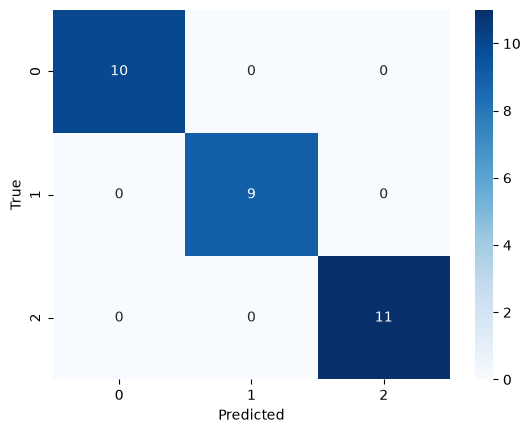

In [40]:
# Plot the Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')

---
<h3 style="color:orange; font-weight:bold">📈 KNN Regression</h3>

KNN Regression is used when the target is a continuous numerical value. It finds the K nearest neighbors and predicts a value based on their nearby target values.

📚 Types
1️⃣ Mean-based Regression → Uses the Mean of nearest neighbors.
2️⃣ Median-based Regression → Uses the Median of nearest neighbors.
🧠 Example

K = 3

Nearest neighbors:

10, 12, 14

Mean = 12 → Prediction = 12

💡 Rule: KNN Regression → Find K nearest neighbors → Calculate Mean/Median → Predict the numerical value.

In [41]:
# Import Liberaries
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [42]:
# Load the Dataset
data = sns.load_dataset('tips')
data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [43]:
# Split the Data into X and y
X = data.drop('tip', axis=1)
y = data['tip']

In [44]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [45]:
# Label Encoding
le = LabelEncoder()
for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype == 'category':
        X[col] = le.fit_transform(X[col])

In [46]:
# Train Test Split the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [47]:
# Call the Model
model = KNeighborsRegressor(n_neighbors=5, metric='minkowski', p=2)   ## I Chose Different Distance Measures

In [48]:

# Fit the Model on the Training Data
model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [49]:
# Predict
y_pred = model.predict(X_test)

In [50]:
# Evaluate the Model
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

Mean Squared Error: 0.8382265306122448
R2 Score: 0.3294034029001649
RMSE: 0.9155471209130881


In [51]:
X_test.head()

,total_bill,sex,smoker,day,time,size
24,19.82,1,0,1,0,2
6,8.77,1,0,2,0,2
153,24.55,1,0,2,0,4
211,25.89,1,1,1,0,4
198,13.00,0,1,3,1,2


In [52]:
# Predict a Specific Value
model.predict([[45, 1, 0, 1, 1, 3]])

c:\ProgramData\miniconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


array([4.946])

---
## 🎯 KNN — Final Takeaway

### 🔑 What We Practiced

* 🧠 Understood how **K value** affects the prediction.
* 📏 Learned that the choice of **distance measure** can affect which neighbors are selected.
* ⚖️ Saw why **feature scaling** is important when distance is used.
* 🎯 Understood why **irrelevant features** can negatively affect KNN predictions.
* ⚠️ Learned that **imbalanced data** can influence majority-based predictions.
* 💻 Understood why KNN can become **computationally expensive** with large datasets.
* 🔧 Learned that choosing a suitable **K value and features** is important for reliable results.

> 💡 **Final Rule:**
> **Good features + appropriate scaling + suitable K → Better KNN performance.**
